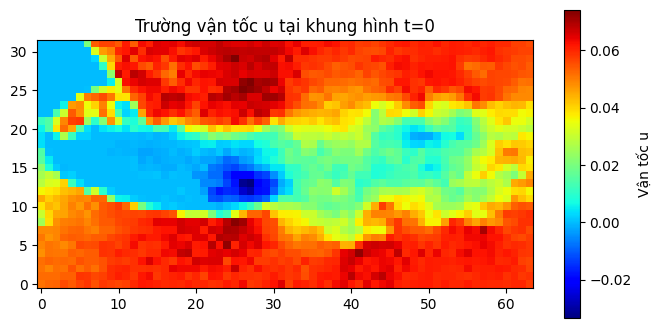

In [11]:
import sys
from pathlib import Path
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == "notebook" else _cwd
for _p in (REPO_ROOT / "src", REPO_ROOT):
    _s = str(_p)
    _ok = _s not in sys.path
    _x = sys.path.insert(0, _s) if _ok else None
import matplotlib.pyplot as plt
from load_baseline import make_example_input

# 1. Đọc thử 1 file dữ liệu thực tế
_h5 = REPO_ROOT / "data" / "train_real" / "3750_20.h5"
assert _h5.exists(), f"missing {_h5}"
x = make_example_input(str(_h5)) # Shape: (1, 20, 32, 64, 3)

# 2. Lấy ra khung hình đầu tiên (t = 0), kênh vận tốc u (c = 0)
u_frame0 = x[0, 0, :, :, 0].cpu().numpy() # Shape: (32, 64)

# 3. Vẽ biểu đồ nhiệt (Heatmap) thể hiện trường vận tốc
plt.figure(figsize=(8, 4))
plt.imshow(u_frame0, cmap='jet', origin='lower')
plt.colorbar(label='Vận tốc u')
plt.title('Trường vận tốc u tại khung hình t=0')
plt.show()

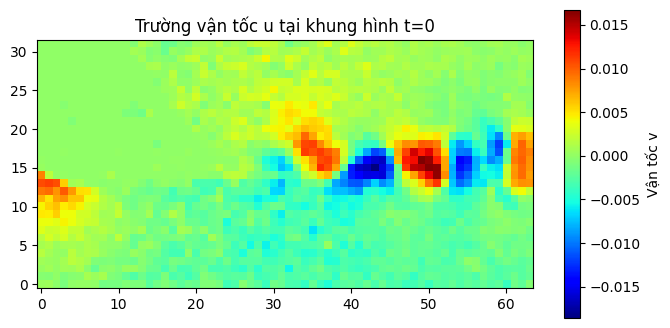

In [5]:
v_frame0 = x[0, 0, :, :, 1].cpu().numpy() # Shape: (32, 64)

# 3. Vẽ biểu đồ nhiệt (Heatmap) thể hiện trường vận tốc
plt.figure(figsize=(8, 4))
plt.imshow(v_frame0, cmap='jet', origin='lower')
plt.colorbar(label='Vận tốc v')
plt.title('Trường vận tốc u tại khung hình t=0')
plt.show()

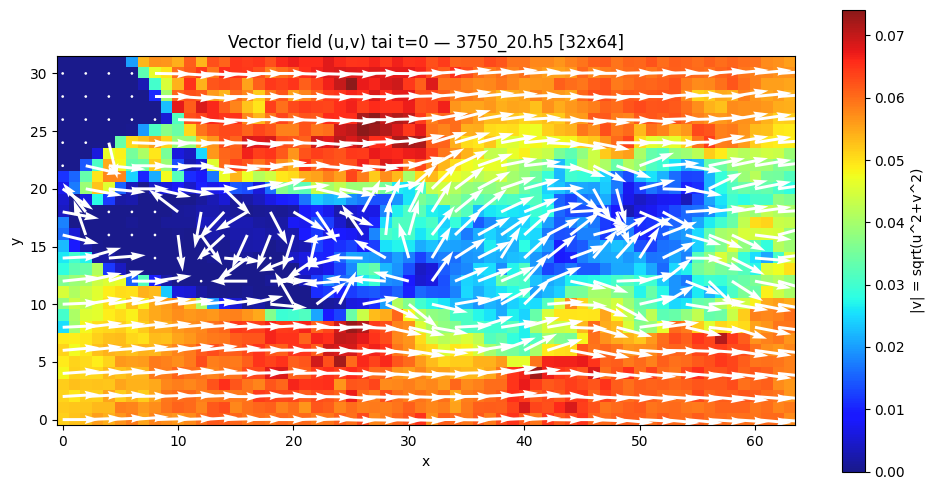

In [12]:
import numpy as np

# 4. Vector field (u, v) tai t=0
u = x[0, 0, :, :, 0].cpu().numpy()  # (H, W)
v = x[0, 0, :, :, 1].cpu().numpy()  # (H, W)
H, W = u.shape
mag = np.sqrt(u**2 + v**2)

# normalize -> unit vectors (huong) + background mag (do lon)
eps = 1e-8
un = u / (mag + eps)
vn = v / (mag + eps)

stride = 2  # thua de mui ten do roi
Y, X = np.mgrid[0:H, 0:W]

plt.figure(figsize=(10, 5))
plt.imshow(mag, cmap='jet', origin='lower', alpha=0.9)
plt.colorbar(label='|v| = sqrt(u^2+v^2)')
plt.quiver(X[::stride, ::stride], Y[::stride, ::stride],
           un[::stride, ::stride], vn[::stride, ::stride],
           color='white', scale=20, width=0.004)  # scale~20 cho unit vector
plt.title(f'Vector field (u,v) tai t=0 — {_h5.name} [{H}x{W}]')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()
